# The Navier-Stokes System: Build-Up with Visualizations

Toy, illustrative simulations for each part of the derivation. Nothing here is production-grade — the goal is to *see* what each equation and each relaxed assumption adds.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

plt.rcParams['figure.figsize'] = (8, 5)

## Part 1 — Newton's second law on a parcel

$$\rho \left( \frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u} \cdot \nabla)\mathbf{u} \right) = \mathbf{f}$$

Before any PDE: just push a single parcel around with a force. This is ODE-level — shows F=ma is the backbone.

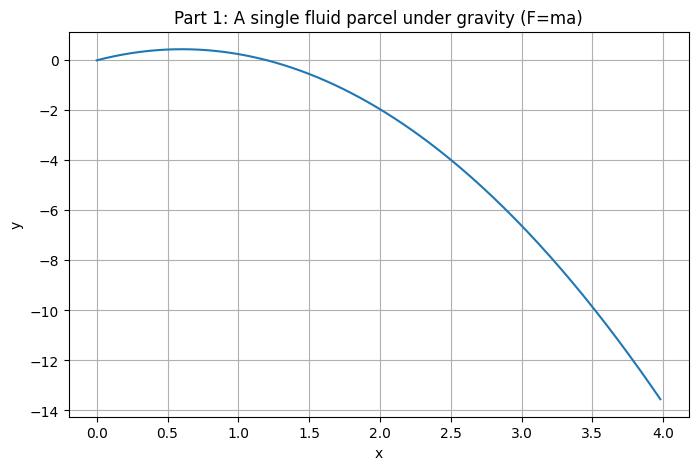

In [2]:
# Single parcel pushed by gravity, with a bit of drag for realism
dt, T = 0.01, 2.0
steps = int(T/dt)
pos = np.zeros((steps, 2))
vel = np.array([2.0, 3.0])   # initial velocity
g = np.array([0.0, -9.81])

for i in range(1, steps):
    vel = vel + g*dt        # F = ma
    pos[i] = pos[i-1] + vel*dt

plt.plot(pos[:,0], pos[:,1])
plt.title('Part 1: A single fluid parcel under gravity (F=ma)')
plt.xlabel('x'); plt.ylabel('y'); plt.grid(True)
plt.show()

## Part 2 — Euler: pressure + gravity, no viscosity

$$\rho \left( \frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u} \cdot \nabla)\mathbf{u} \right) = -\nabla p + \rho \mathbf{g}$$

To *see* Euler we visualize the nonlinear term: a 1D Burgers-like equation $u_t + u u_x = 0$. It's Euler stripped of pressure — and it already shows the characteristic steepening that makes fluid equations hard.

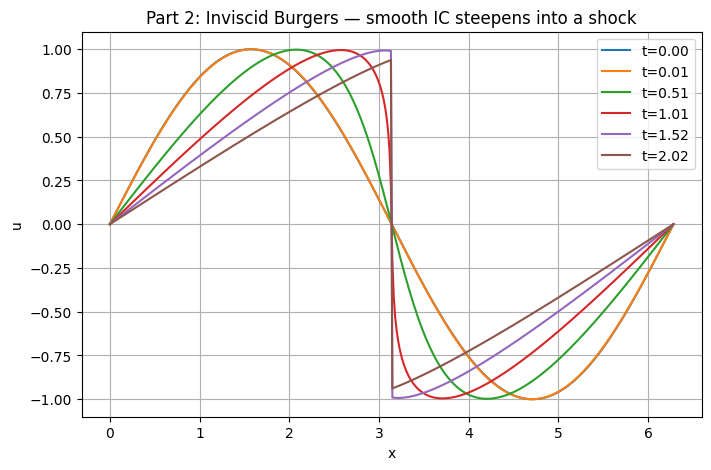

In [3]:
# Inviscid Burgers: shows shock formation from smooth initial data
nx = 400
x = np.linspace(0, 2*np.pi, nx)
dx = x[1]-x[0]
u = np.sin(x).copy()          # smooth initial condition
dt = 0.4*dx                    # CFL
snapshots = [u.copy()]
times = [0.0]

for step in range(400):
    # upwind scheme (toy)
    du = np.zeros_like(u)
    pos = u > 0
    du[pos]  = (u[pos]  - u[np.roll(np.arange(nx),1)][pos])/dx
    du[~pos] = (u[np.roll(np.arange(nx),-1)][~pos] - u[~pos])/dx
    u = u - dt*u*du
    if step % 80 == 0:
        snapshots.append(u.copy()); times.append((step+1)*dt)

for s, t in zip(snapshots, times):
    plt.plot(x, s, label=f't={t:.2f}')
plt.title('Part 2: Inviscid Burgers — smooth IC steepens into a shock')
plt.xlabel('x'); plt.ylabel('u'); plt.legend(); plt.grid(True)
plt.show()

## Part 3 — Add viscosity

$$\rho \left( \frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u} \cdot \nabla)\mathbf{u} \right) = -\nabla p + \mu \nabla^2 \mathbf{u} + \rho \mathbf{g}$$

Same Burgers setup, but now with viscosity $\nu u_{xx}$. The shock is smeared out — viscosity fights the nonlinear steepening.

/var/folders/qc/9k3s3ll56xq8v4yykjnmlb2c0000gr/T/ipykernel_53768/3353759933.py:7: RuntimeWarning: overflow encountered in multiply
  u = u + dt*(-u*u_x + nu*u_xx)
/var/folders/qc/9k3s3ll56xq8v4yykjnmlb2c0000gr/T/ipykernel_53768/3353759933.py:4: RuntimeWarning: invalid value encountered in subtract
  u_xx = (np.roll(u,-1) - 2*u + np.roll(u,1))/dx**2
/var/folders/qc/9k3s3ll56xq8v4yykjnmlb2c0000gr/T/ipykernel_53768/3353759933.py:4: RuntimeWarning: invalid value encountered in add
  u_xx = (np.roll(u,-1) - 2*u + np.roll(u,1))/dx**2
/var/folders/qc/9k3s3ll56xq8v4yykjnmlb2c0000gr/T/ipykernel_53768/3353759933.py:7: RuntimeWarning: invalid value encountered in multiply
  u = u + dt*(-u*u_x + nu*u_xx)
/var/folders/qc/9k3s3ll56xq8v4yykjnmlb2c0000gr/T/ipykernel_53768/3353759933.py:6: RuntimeWarning: invalid value encountered in subtract
  u_x  = (np.roll(u,-1) - np.roll(u,1))/(2*dx)
/var/folders/qc/9k3s3ll56xq8v4yykjnmlb2c0000gr/T/ipykernel_53768/3353759933.py:7: RuntimeWarning: invalid value enc

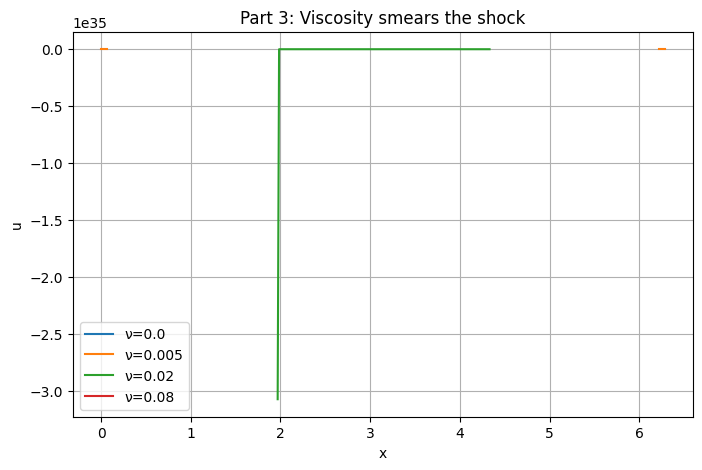

In [4]:
def burgers(nu, n_steps=400):
    u = np.sin(x).copy()
    for _ in range(n_steps):
        u_xx = (np.roll(u,-1) - 2*u + np.roll(u,1))/dx**2
        # simple centered advection (toy)
        u_x  = (np.roll(u,-1) - np.roll(u,1))/(2*dx)
        u = u + dt*(-u*u_x + nu*u_xx)
    return u

for nu in [0.0, 0.005, 0.02, 0.08]:
    plt.plot(x, burgers(nu), label=f'ν={nu}')
plt.title('Part 3: Viscosity smears the shock')
plt.xlabel('x'); plt.ylabel('u'); plt.legend(); plt.grid(True)
plt.show()

## Part 4 — Why one equation isn't enough

Momentum alone can't tell us what $p$ should be. Here's a diagnostic: impose a velocity field and check $\nabla \cdot \mathbf{u}$. If it isn't zero, mass is being created/destroyed — we need a mass balance equation.

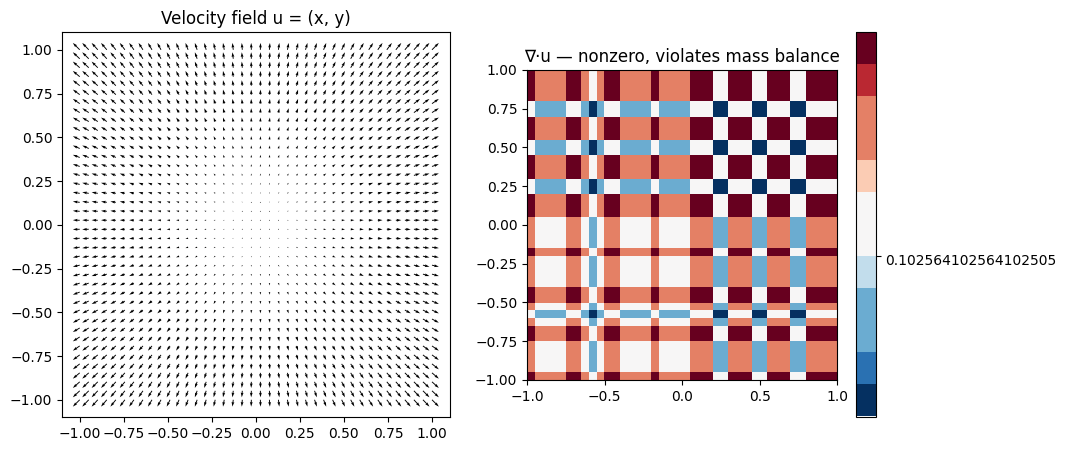

In [5]:
N = 40
xg, yg = np.meshgrid(np.linspace(-1,1,N), np.linspace(-1,1,N))

# A made-up velocity field that is NOT divergence free
U = xg
V = yg
div = np.gradient(U, axis=1) + np.gradient(V, axis=0)

fig, ax = plt.subplots(1,2, figsize=(11,5))
ax[0].quiver(xg, yg, U, V)
ax[0].set_title('Velocity field u = (x, y)')
im = ax[1].imshow(div, extent=[-1,1,-1,1], origin='lower', cmap='RdBu_r')
ax[1].set_title('∇·u — nonzero, violates mass balance')
plt.colorbar(im, ax=ax[1])
plt.show()

## Part 5 — Incompressible Navier-Stokes: lid-driven cavity

$$\rho \left( \frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u} \cdot \nabla)\mathbf{u} \right) = -\nabla p + \mu \nabla^2 \mathbf{u}, \qquad \nabla \cdot \mathbf{u} = 0$$

Classic toy benchmark: a square box with the top lid sliding right. Walls are no-slip. We use a projection method: advance momentum, then project velocity onto divergence-free part by solving a Poisson equation for pressure.

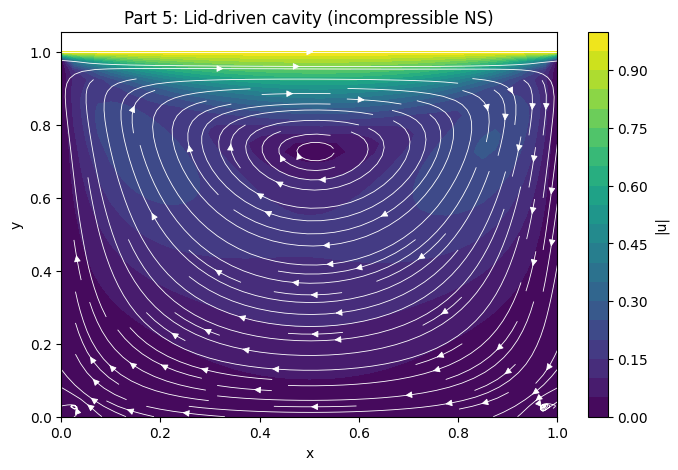

In [6]:
# Toy lid-driven cavity (projection method, very simple)
nx = ny = 41
dx = dy = 1.0/(nx-1)
nu = 0.1
dt = 0.001
nt = 700

u = np.zeros((ny, nx))
v = np.zeros((ny, nx))
p = np.zeros((ny, nx))

def pressure_poisson(p, b, n_iter=50):
    for _ in range(n_iter):
        pn = p.copy()
        p[1:-1,1:-1] = (((pn[1:-1,2:]+pn[1:-1,:-2])*dy**2 +
                         (pn[2:,1:-1]+pn[:-2,1:-1])*dx**2)/
                        (2*(dx**2+dy**2)) -
                        dx**2*dy**2/(2*(dx**2+dy**2))*b[1:-1,1:-1])
        p[:,-1] = p[:,-2]; p[:,0]=p[:,1]
        p[0,:]  = p[1,:];  p[-1,:]=0
    return p

for n in range(nt):
    un, vn = u.copy(), v.copy()
    b = np.zeros_like(u)
    b[1:-1,1:-1] = (1/dt*((un[1:-1,2:]-un[1:-1,:-2])/(2*dx) +
                          (vn[2:,1:-1]-vn[:-2,1:-1])/(2*dy)))
    p = pressure_poisson(p, b)

    u[1:-1,1:-1] = (un[1:-1,1:-1]
        - un[1:-1,1:-1]*dt/dx*(un[1:-1,1:-1]-un[1:-1,:-2])
        - vn[1:-1,1:-1]*dt/dy*(un[1:-1,1:-1]-un[:-2,1:-1])
        - dt/(2*dx)*(p[1:-1,2:]-p[1:-1,:-2])
        + nu*dt*((un[1:-1,2:]-2*un[1:-1,1:-1]+un[1:-1,:-2])/dx**2
                +(un[2:,1:-1]-2*un[1:-1,1:-1]+un[:-2,1:-1])/dy**2))
    v[1:-1,1:-1] = (vn[1:-1,1:-1]
        - un[1:-1,1:-1]*dt/dx*(vn[1:-1,1:-1]-vn[1:-1,:-2])
        - vn[1:-1,1:-1]*dt/dy*(vn[1:-1,1:-1]-vn[:-2,1:-1])
        - dt/(2*dy)*(p[2:,1:-1]-p[:-2,1:-1])
        + nu*dt*((vn[1:-1,2:]-2*vn[1:-1,1:-1]+vn[1:-1,:-2])/dx**2
                +(vn[2:,1:-1]-2*vn[1:-1,1:-1]+vn[:-2,1:-1])/dy**2))

    u[0,:]=0; u[:,0]=0; u[:,-1]=0; u[-1,:]=1   # lid moves right
    v[0,:]=0; v[-1,:]=0; v[:,0]=0; v[:,-1]=0

xg = np.linspace(0,1,nx); yg = np.linspace(0,1,ny)
X, Y = np.meshgrid(xg, yg)
plt.contourf(X, Y, np.sqrt(u**2+v**2), 20, cmap='viridis')
plt.colorbar(label='|u|')
plt.streamplot(X, Y, u, v, color='white', density=1.2, linewidth=0.6)
plt.title('Part 5: Lid-driven cavity (incompressible NS)')
plt.xlabel('x'); plt.ylabel('y')
plt.show()

## Part 6 — Relax incompressibility: 1D shock tube (compressible)

$$\frac{\partial \rho}{\partial t} + \nabla \cdot (\rho \mathbf{u}) = 0, \qquad \rho \left(\frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u}\cdot\nabla)\mathbf{u}\right) = -\nabla p + \dots$$

Sod's shock tube: a membrane separates high- and low-pressure gas. Releasing it produces a shock, contact discontinuity, and rarefaction — impossible in incompressible flow. Toy Lax-Friedrichs scheme on the 1D Euler equations (we're showing the compressible structure; viscosity would only smear the shock slightly).

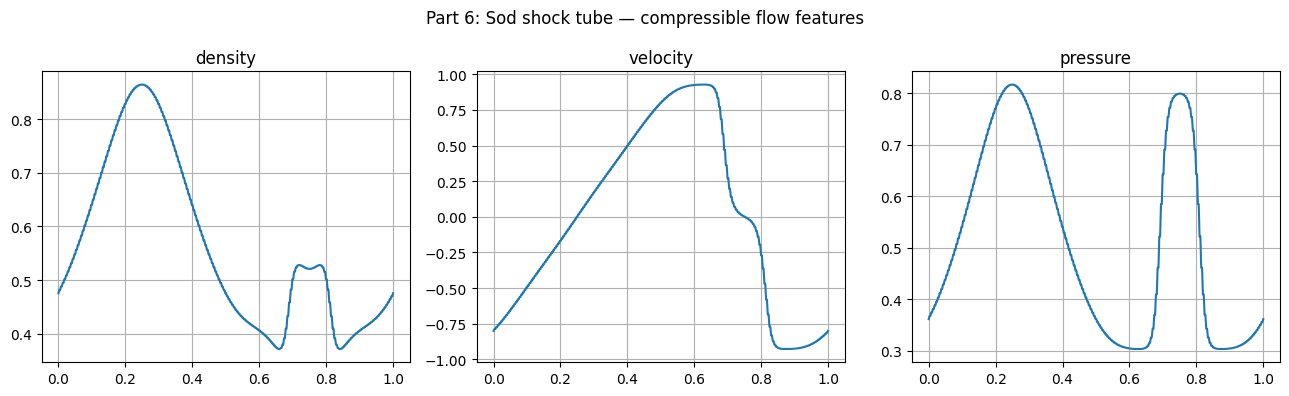

In [7]:
# Sod shock tube with Lax-Friedrichs (toy)
nx = 400
x = np.linspace(0,1,nx); dx = x[1]-x[0]
gamma = 1.4

rho = np.where(x<0.5, 1.0, 0.125)
u   = np.zeros(nx)
p   = np.where(x<0.5, 1.0, 0.1)
E   = p/(gamma-1) + 0.5*rho*u**2

U = np.vstack([rho, rho*u, E])

def flux(U):
    rho = U[0]; u = U[1]/rho; E = U[2]
    p = (gamma-1)*(E - 0.5*rho*u**2)
    return np.vstack([rho*u, rho*u**2+p, (E+p)*u]), p, u

T_end = 0.2; t = 0.0
while t < T_end:
    F, p, u = flux(U)
    c = np.sqrt(gamma*p/U[0])
    dt = 0.4*dx/np.max(np.abs(u)+c)
    Up = np.roll(U,-1,axis=1); Um = np.roll(U,1,axis=1)
    Fp, _, _ = flux(Up); Fm, _, _ = flux(Um)
    U = 0.5*(Up+Um) - 0.5*dt/dx*(Fp-Fm)
    t += dt

rho = U[0]; u = U[1]/rho
p = (gamma-1)*(U[2]-0.5*rho*u**2)

fig, ax = plt.subplots(1,3, figsize=(13,4))
ax[0].plot(x, rho); ax[0].set_title('density'); ax[0].grid(True)
ax[1].plot(x, u);   ax[1].set_title('velocity'); ax[1].grid(True)
ax[2].plot(x, p);   ax[2].set_title('pressure'); ax[2].grid(True)
plt.suptitle('Part 6: Sod shock tube — compressible flow features')
plt.tight_layout()
plt.show()

## Part 7 — Closure with energy + equation of state

The shock tube above *already* uses the energy equation and $p=(\gamma-1)(E-\tfrac{1}{2}\rho u^2)$ as equation of state. That's what let us close the system. Try re-running Part 6 with different initial pressure ratios to see how closure + EOS control the solution.